# Step 1: Exploratory Data Analysis
**Store Sales — Time Series Forecasting (Favorita Grocery)**

Dataset: Ecuador Favorita supermarket sales records, 2013–2017

Sections:
1. Load Data
2. Basic Info & Missing Values
3. Sales Distribution
4. Time Series Trends
5. Sales by Product Family
6. Sales by Store
7. Oil Price Analysis
8. Holiday Impact
9. Promotion Impact
10. Transactions Analysis
11. EDA Summary

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = 'data/'

## 1. Load Data

In [40]:
train        = pd.read_csv(DATA_DIR + 'train.csv',           parse_dates=['date'])
test         = pd.read_csv(DATA_DIR + 'test.csv',            parse_dates=['date'])
stores       = pd.read_csv(DATA_DIR + 'stores.csv')
oil          = pd.read_csv(DATA_DIR + 'oil.csv',             parse_dates=['date'])
holidays     = pd.read_csv(DATA_DIR + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(DATA_DIR + 'transactions.csv',    parse_dates=['date'])

print('train:       ', train.shape)
print('test:        ', test.shape)
print('stores:      ', stores.shape)
print('oil:         ', oil.shape)
print('holidays:    ', holidays.shape)
print('transactions:', transactions.shape)

train:        (3000888, 6)
test:         (28512, 5)
stores:       (54, 5)
oil:          (1218, 2)
holidays:     (350, 6)
transactions: (83488, 3)


## 2. Basic Info & Missing Values

In [41]:
def summarize(df, name):
    print(f'\n===== {name} =====')
    print(df.dtypes.to_frame('dtype').join(
        df.isnull().sum().to_frame('missing')
    ).assign(missing_pct=lambda x: (x['missing'] / len(df) * 100).round(2)))
    print(df.describe(include='all').T[['count', 'mean', 'min', 'max']].dropna(how='all'))

for df, name in [(train, 'train'), (stores, 'stores'),
                 (oil, 'oil'), (holidays, 'holidays'),
                 (transactions, 'transactions')]:
    summarize(df, name)


===== train =====
                      dtype  missing  missing_pct
id                    int64        0          0.0
date         datetime64[ns]        0          0.0
store_nbr             int64        0          0.0
family               object        0          0.0
sales               float64        0          0.0
onpromotion           int64        0          0.0
                 count                           mean                  min  \
id           3000888.0                      1500443.5                  0.0   
date           3000888  2015-04-24 08:27:04.703088384  2013-01-01 00:00:00   
store_nbr    3000888.0                           27.5                  1.0   
family         3000888                            NaN                  NaN   
sales        3000888.0                     357.775749                  0.0   
onpromotion  3000888.0                        2.60277                  0.0   

                             max  
id                     3000887.0  
date         2

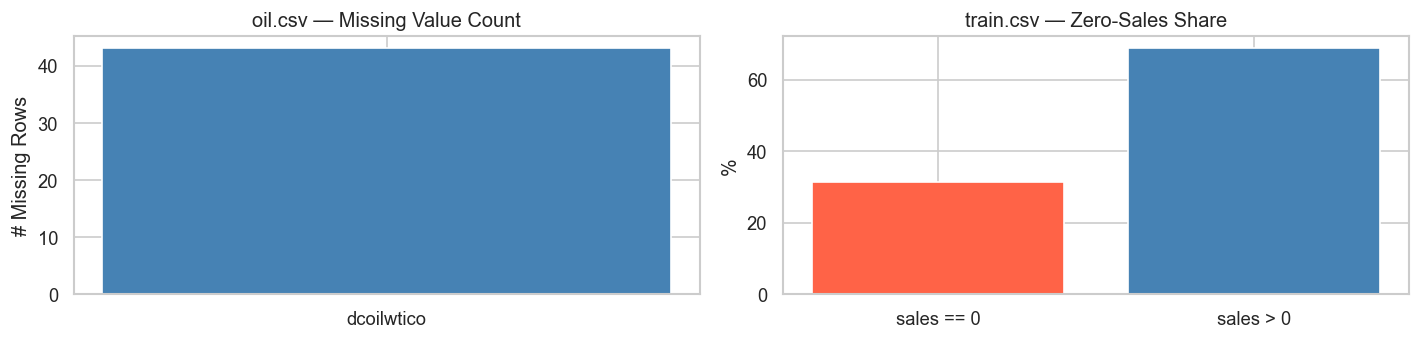

Zero-sales records: 31.3%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Missing values in oil
axes[0].bar(['dcoilwtico'], [oil['dcoilwtico'].isnull().sum()], color='steelblue')
axes[0].set_title('oil.csv — Missing Value Count')
axes[0].set_ylabel('# Missing Rows')

# Zero-sales share in train
zero_pct = (train['sales'] == 0).mean() * 100
axes[1].bar(['sales == 0', 'sales > 0'], [zero_pct, 100 - zero_pct], color=['tomato', 'steelblue'])
axes[1].set_title('train.csv — Zero-Sales Share')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

print(f'Zero-sales records: {zero_pct:.1f}%')

## 3. Sales Distribution

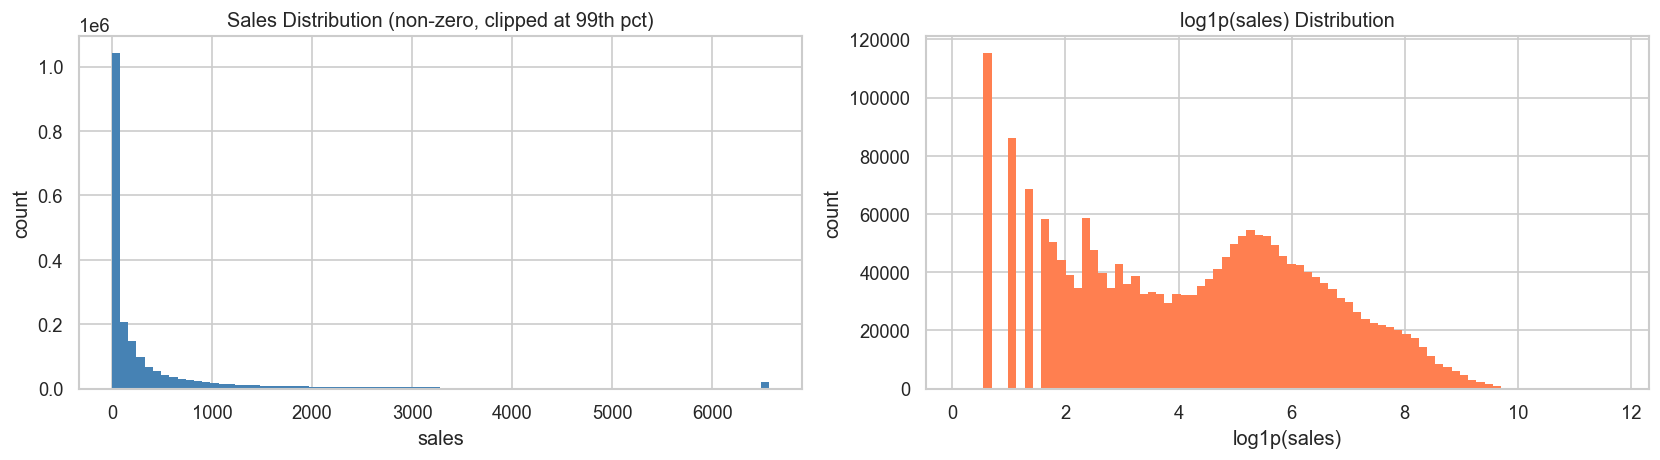

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

nonzero = train.loc[train['sales'] > 0, 'sales']

# Raw distribution (clipped at 99th percentile)
axes[0].hist(nonzero.clip(upper=nonzero.quantile(0.99)), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Sales Distribution (non-zero, clipped at 99th pct)')
axes[0].set_xlabel('sales')
axes[0].set_ylabel('count')

# After log1p transform
axes[1].hist(np.log1p(nonzero), bins=80, color='coral', edgecolor='none')
axes[1].set_title('log1p(sales) Distribution')
axes[1].set_xlabel('log1p(sales)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## 4. Time Series Trends

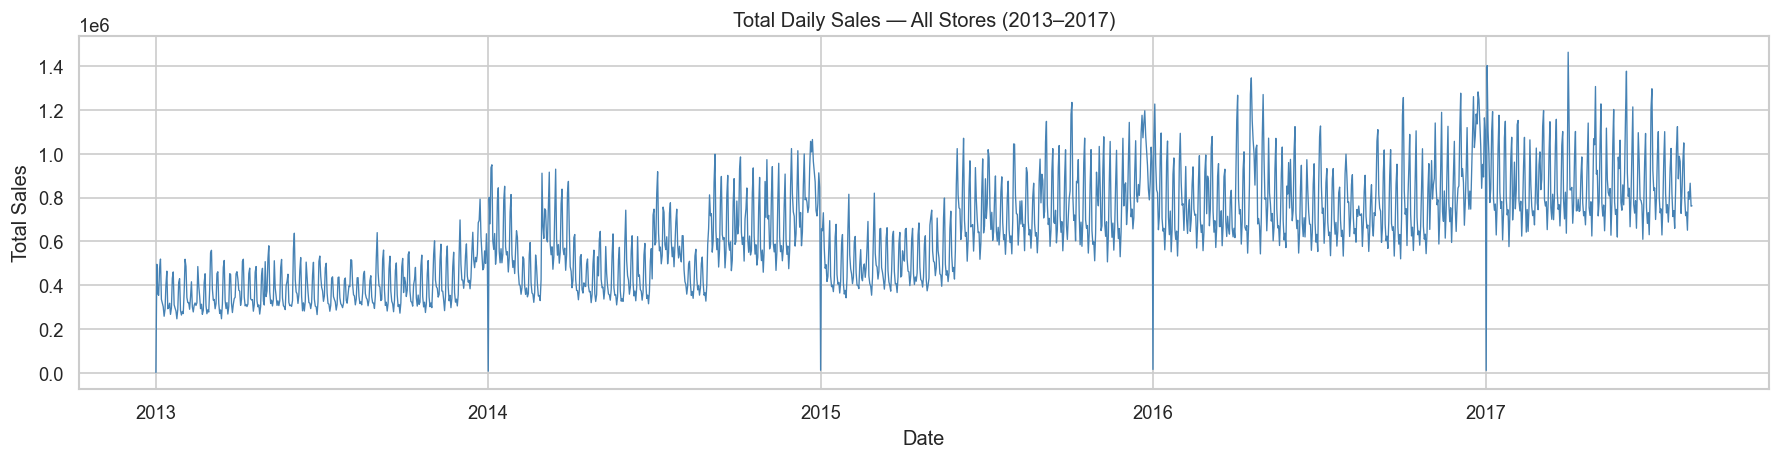

In [44]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily_sales['date'], daily_sales['sales'], linewidth=0.8, color='steelblue')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Total Daily Sales — All Stores (2013–2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

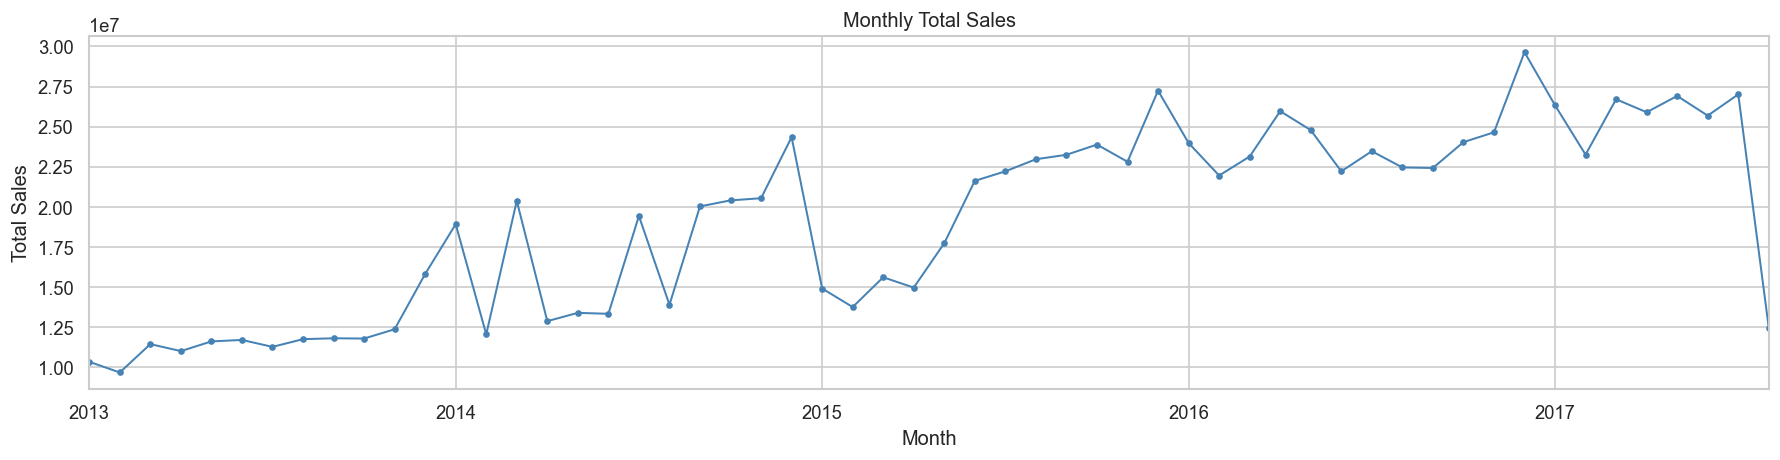

In [45]:
# Monthly trend (smoother)
train['year_month'] = train['date'].dt.to_period('M')
monthly_sales = train.groupby('year_month')['sales'].sum()

fig, ax = plt.subplots(figsize=(15, 4))
monthly_sales.plot(ax=ax, color='steelblue', marker='o', markersize=3, linewidth=1.2)
ax.set_title('Monthly Total Sales')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

train.drop(columns='year_month', inplace=True)

## 5. Sales by Product Family

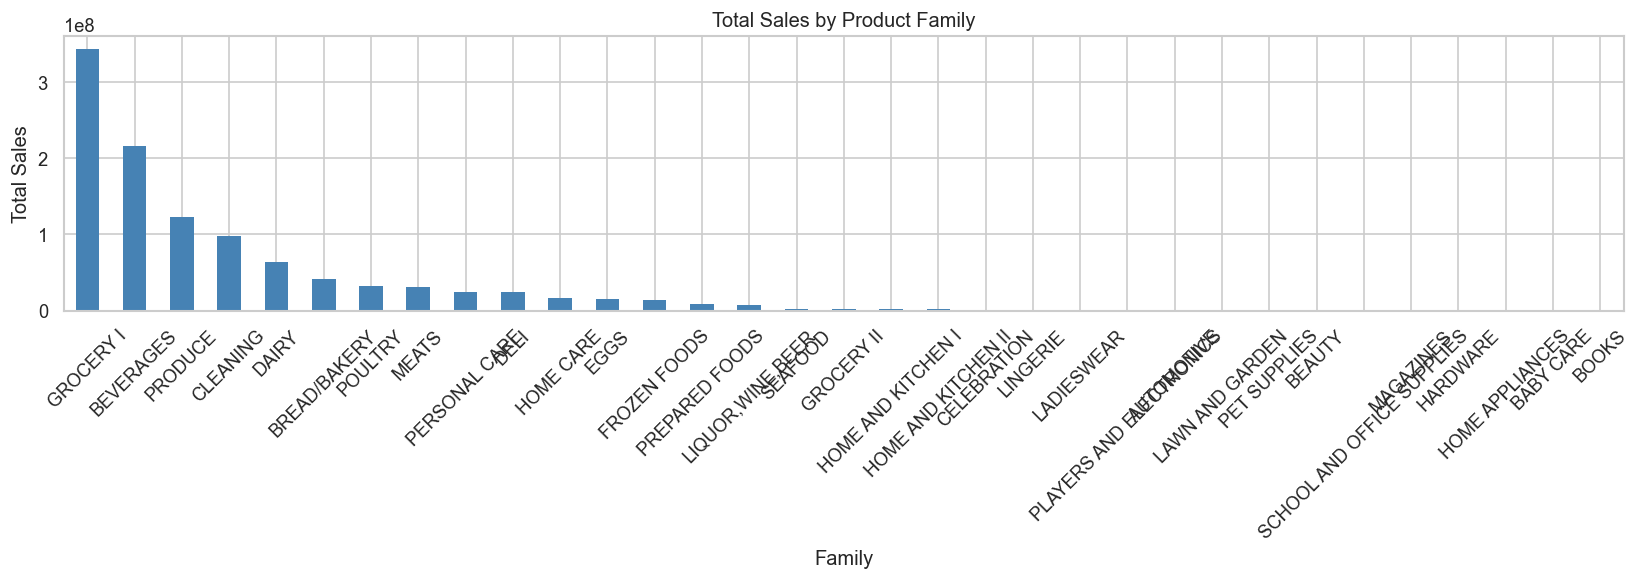

Top 5 families:
family
GROCERY I    3.434627e+08
BEVERAGES    2.169545e+08
PRODUCE      1.227047e+08
CLEANING     9.752129e+07
DAIRY        6.448771e+07
Name: sales, dtype: float64


In [46]:
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
family_sales.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Total Sales by Product Family')
ax.set_xlabel('Family')
ax.set_ylabel('Total Sales')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Top 5 families:')
print(family_sales.head())

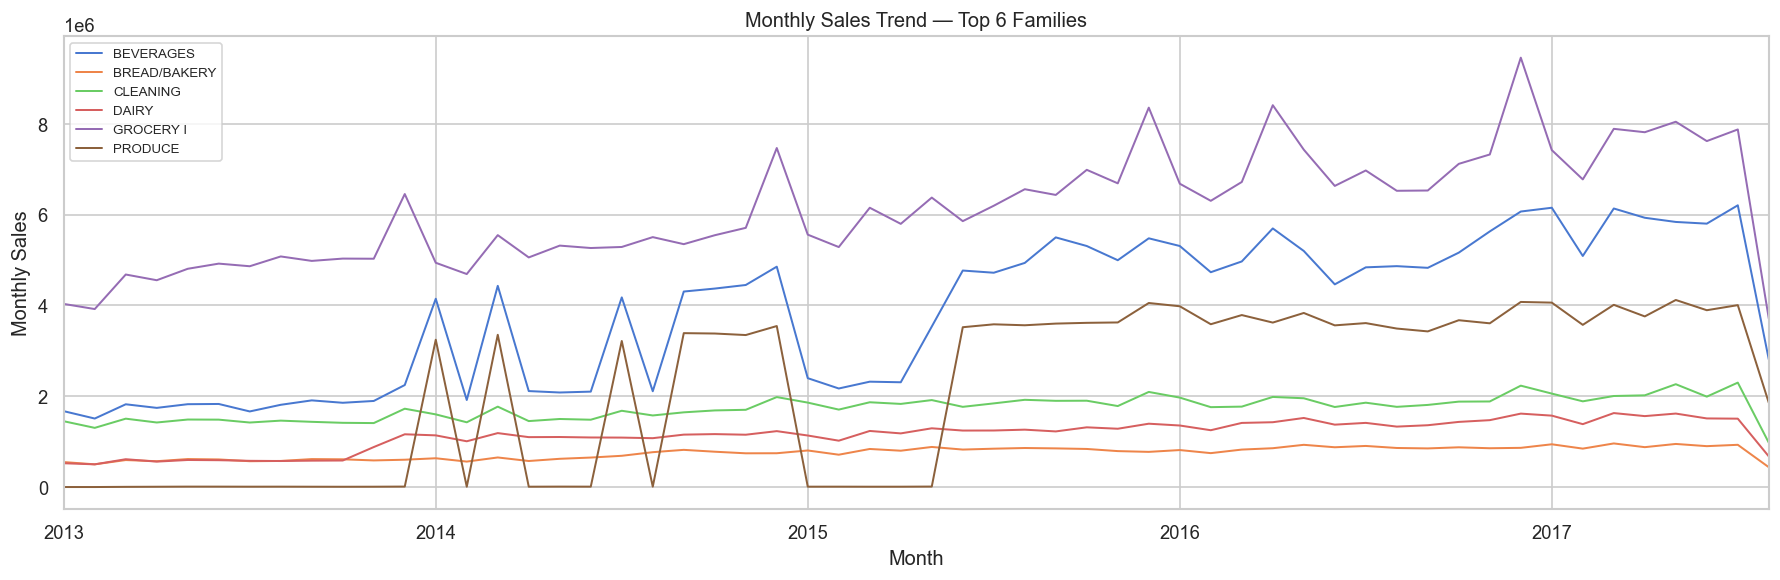

In [47]:
# Monthly trend for top 6 families
top6 = family_sales.head(6).index.tolist()
top6_data = train[train['family'].isin(top6)].copy()
top6_data['year_month'] = top6_data['date'].dt.to_period('M')
top6_pivot = top6_data.groupby(['year_month', 'family'])['sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(15, 5))
top6_pivot.plot(ax=ax, linewidth=1.2)
ax.set_title('Monthly Sales Trend — Top 6 Families')
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Sales')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Sales by Store

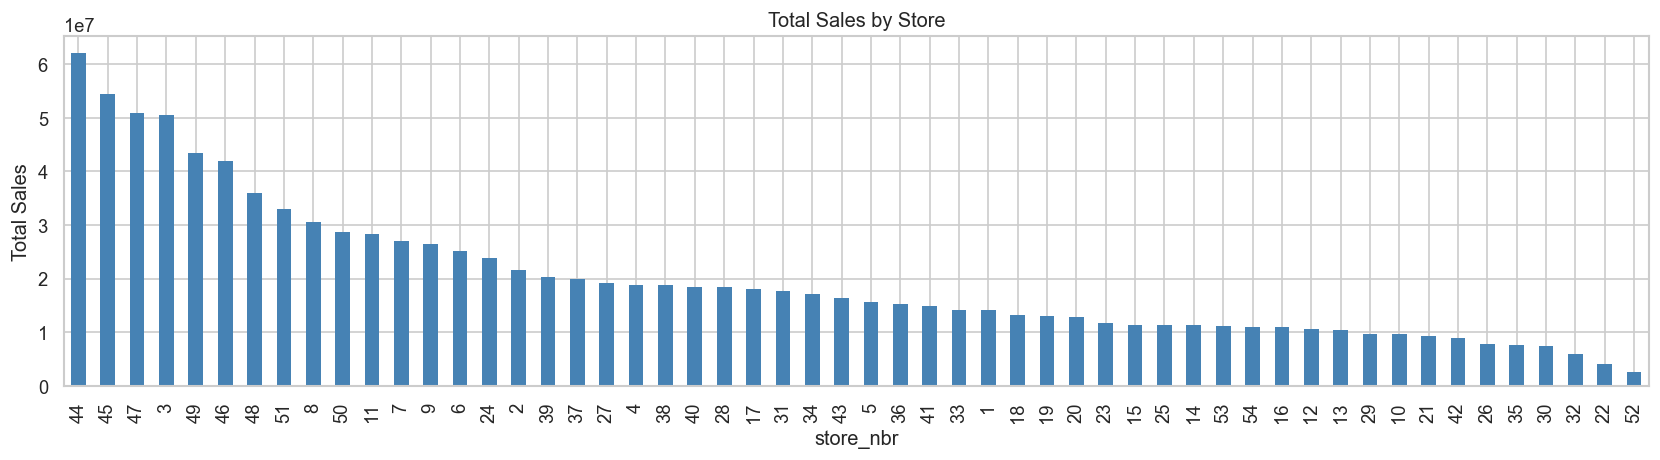

Top 5 stores by sales:    [44, 45, 47, 3, 49]
Bottom 5 stores by sales: [35, 30, 32, 22, 52]


In [48]:
store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
store_sales.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Total Sales by Store')
ax.set_xlabel('store_nbr')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

print('Top 5 stores by sales:   ', store_sales.head().index.tolist())
print('Bottom 5 stores by sales:', store_sales.tail().index.tolist())

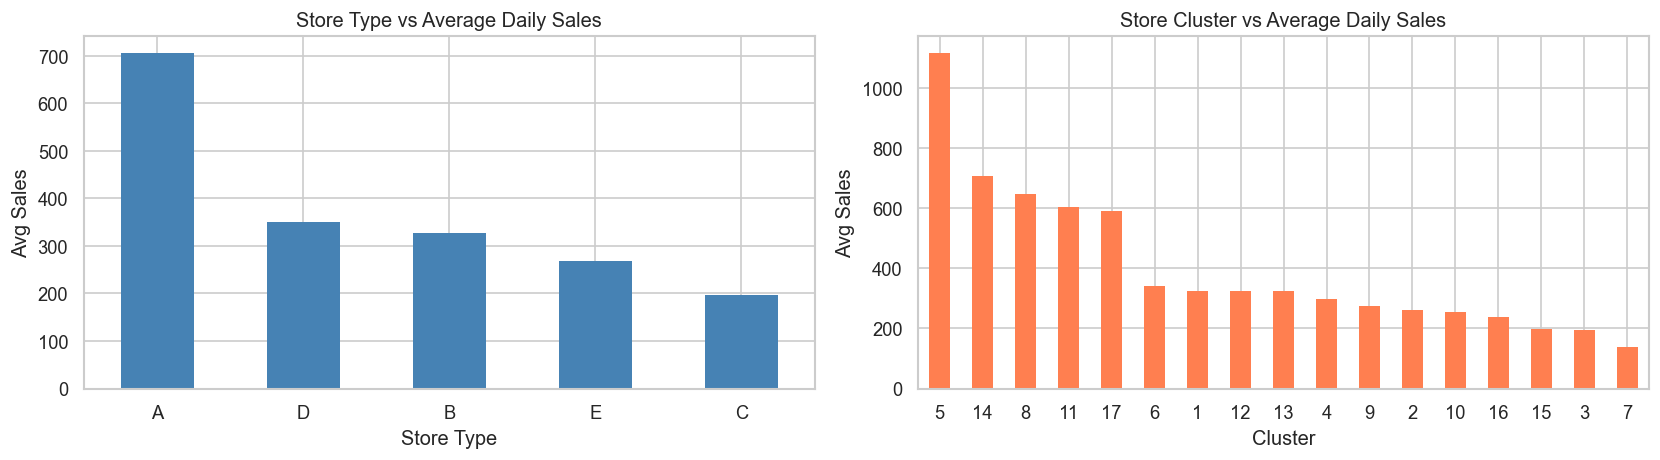

In [49]:
# Store type and cluster vs average sales
store_type_sales = train.merge(stores[['store_nbr', 'type', 'cluster']], on='store_nbr')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_avg = store_type_sales.groupby('type')['sales'].mean().sort_values(ascending=False)
type_avg.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Store Type vs Average Daily Sales')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Avg Sales')
axes[0].tick_params(axis='x', rotation=0)

cluster_avg = store_type_sales.groupby('cluster')['sales'].mean().sort_values(ascending=False)
cluster_avg.plot(kind='bar', ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('Store Cluster vs Average Daily Sales')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Sales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Oil Price Analysis

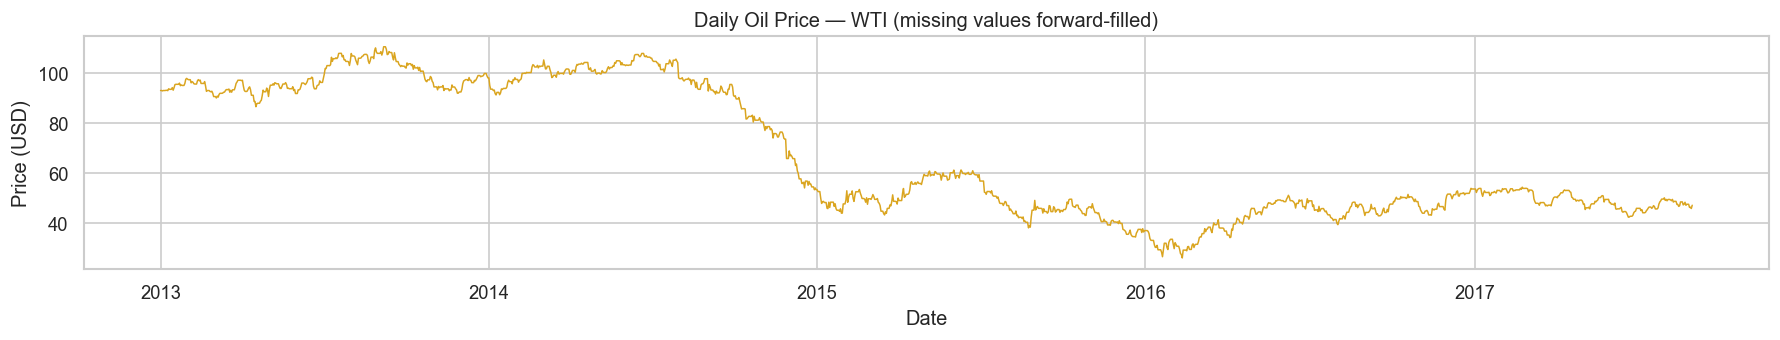

In [50]:
oil_filled = oil.set_index('date').resample('D').first().ffill().bfill().reset_index()

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(oil_filled['date'], oil_filled['dcoilwtico'], color='goldenrod', linewidth=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Daily Oil Price — WTI (missing values forward-filled)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

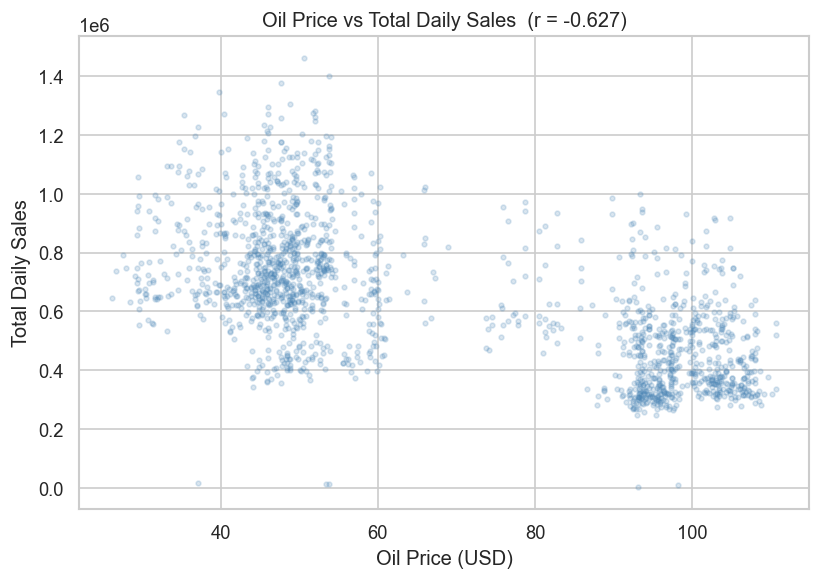

In [51]:
# Correlation: oil price vs total daily sales
merged_oil = daily_sales.merge(
    oil_filled.rename(columns={'dcoilwtico': 'oil_price'}), on='date', how='left'
)
r = merged_oil[['oil_price', 'sales']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged_oil['oil_price'], merged_oil['sales'], alpha=0.2, s=8, color='steelblue')
ax.set_title(f'Oil Price vs Total Daily Sales  (r = {r:.3f})')
ax.set_xlabel('Oil Price (USD)')
ax.set_ylabel('Total Daily Sales')
plt.tight_layout()
plt.show()

## 8. Holiday Impact

In [52]:
print('Holiday type distribution:')
print(holidays['type'].value_counts())
print('\nLocale distribution:')
print(holidays['locale'].value_counts())

Holiday type distribution:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

Locale distribution:
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64


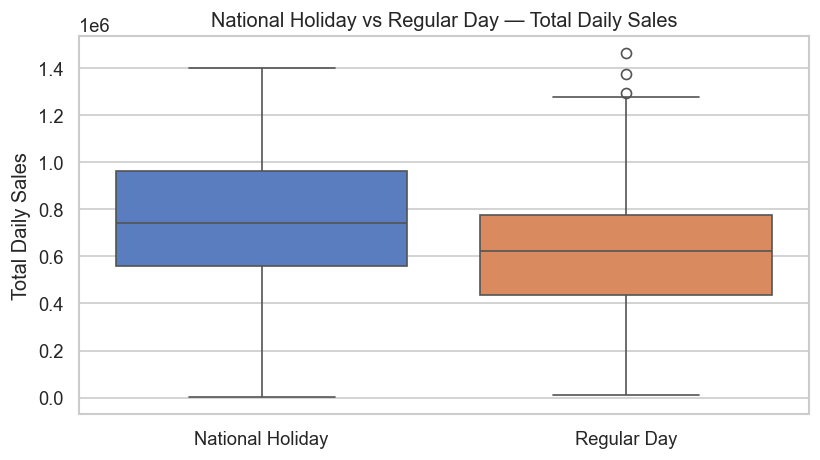

                           mean         median
label                                         
National Holiday  747262.613625  742923.217484
Regular Day       627918.111596  624754.402274


In [53]:
# National holidays vs regular days
national_holidays = holidays[
    (holidays['locale'] == 'National') & (holidays['transferred'] == False)
][['date']].drop_duplicates().assign(is_holiday=True)

daily_with_holiday = daily_sales.merge(national_holidays, on='date', how='left')
daily_with_holiday['is_holiday'] = daily_with_holiday['is_holiday'].fillna(False)
daily_with_holiday['label'] = daily_with_holiday['is_holiday'].map(
    {True: 'National Holiday', False: 'Regular Day'}
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=daily_with_holiday, x='label', y='sales', ax=ax, palette='muted')
ax.set_title('National Holiday vs Regular Day — Total Daily Sales')
ax.set_xlabel('')
ax.set_ylabel('Total Daily Sales')
plt.tight_layout()
plt.show()

print(daily_with_holiday.groupby('label')['sales'].agg(['mean', 'median']))

## 9. Promotion Impact

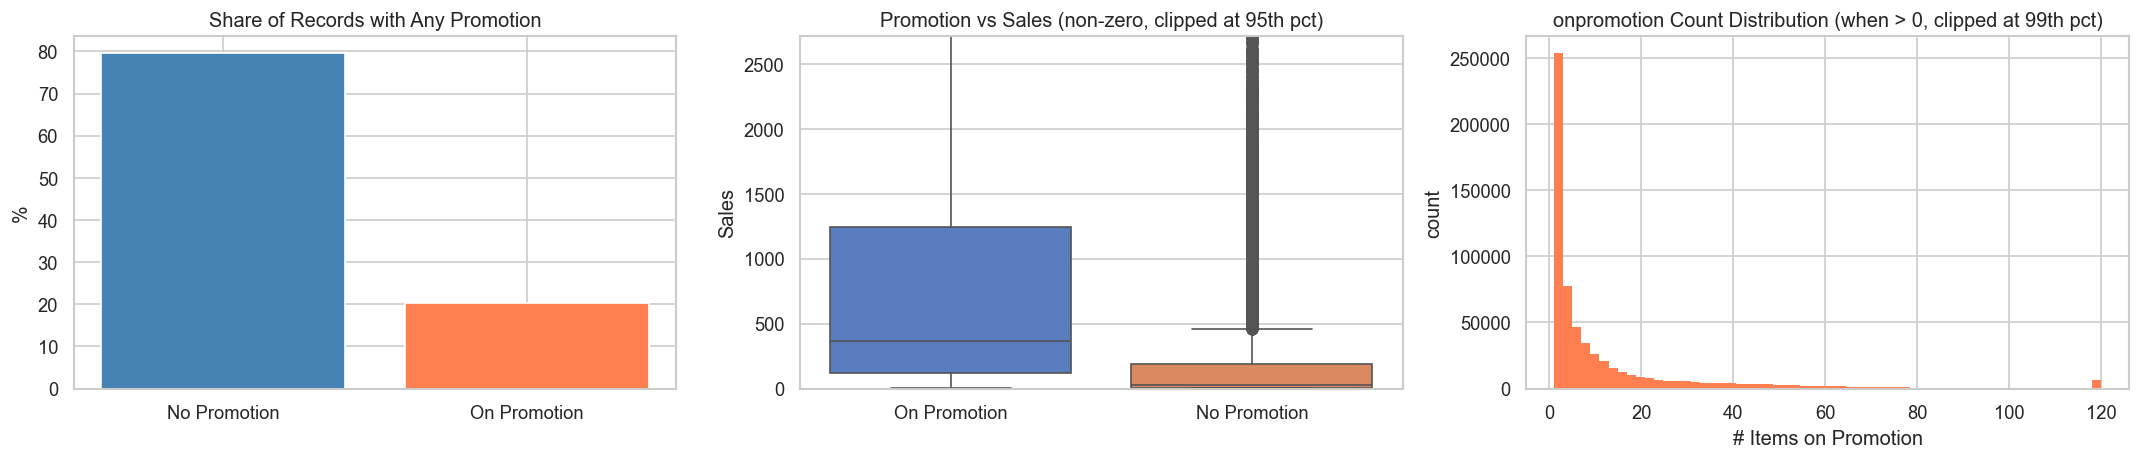

                     mean      median
on_promo                             
No Promotion   260.705867   25.647499
On Promotion  1137.725368  373.000000

promotion range: 0 – 741 (count of SKUs on promotion, not a binary flag)


In [54]:
# onpromotion is a COUNT (0–741), not a binary flag
# Create a binary label: any promotion vs no promotion
promo_nonzero = train[train['sales'] > 0].copy()
promo_nonzero['on_promo'] = (promo_nonzero['onpromotion'] > 0).map({False: 'No Promotion', True: 'On Promotion'})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Share of records with any promotion
promo_share = (train['onpromotion'] > 0).value_counts(normalize=True) * 100
axes[0].bar(['No Promotion', 'On Promotion'],
            [promo_share.get(False, 0), promo_share.get(True, 0)],
            color=['steelblue', 'coral'])
axes[0].set_title('Share of Records with Any Promotion')
axes[0].set_ylabel('%')

# Sales distribution: promotion vs no promotion
sns.boxplot(
    data=promo_nonzero.sample(50000, random_state=42),
    x='on_promo', y='sales', ax=axes[1], palette='muted'
)
axes[1].set_ylim(0, promo_nonzero['sales'].quantile(0.95))
axes[1].set_title('Promotion vs Sales (non-zero, clipped at 95th pct)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sales')

# Distribution of onpromotion count (non-zero only)
promo_counts = train[train['onpromotion'] > 0]['onpromotion']
axes[2].hist(promo_counts.clip(upper=promo_counts.quantile(0.99)), bins=60, color='coral', edgecolor='none')
axes[2].set_title('onpromotion Count Distribution (when > 0, clipped at 99th pct)')
axes[2].set_xlabel('# Items on Promotion')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

print(promo_nonzero.groupby('on_promo')['sales'].agg(['mean', 'median']))
print(f'\npromotion range: 0 – {train["onpromotion"].max()} (count of SKUs on promotion, not a binary flag)')

## 10. Transactions Analysis

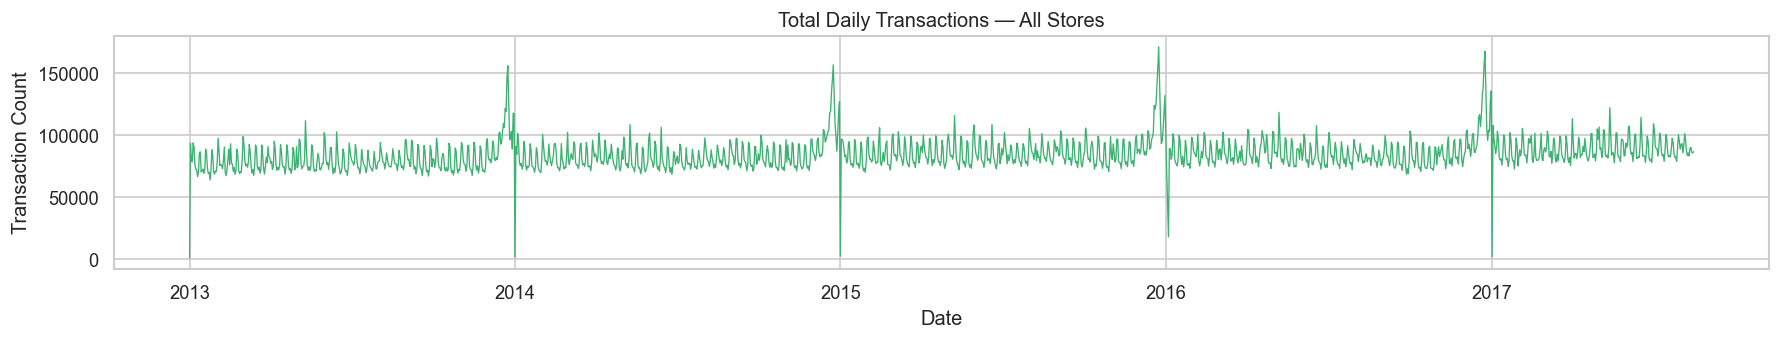

In [55]:
daily_tx = transactions.groupby('date')['transactions'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(daily_tx['date'], daily_tx['transactions'], linewidth=0.8, color='mediumseagreen')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Total Daily Transactions — All Stores')
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Count')
plt.tight_layout()
plt.show()

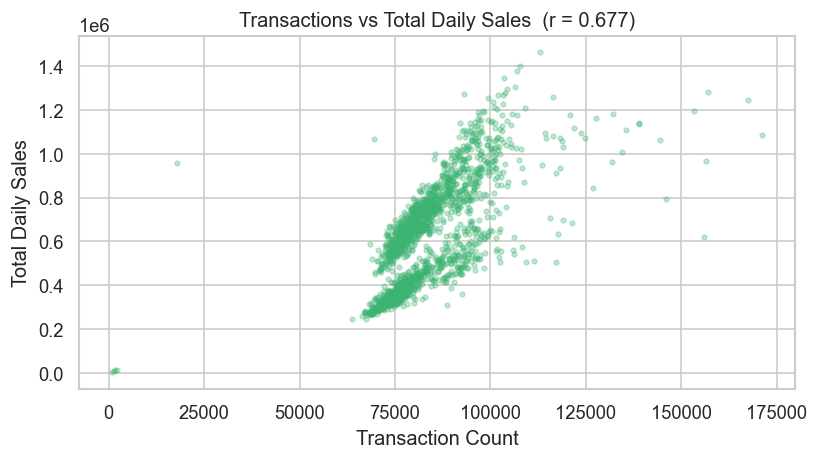

In [56]:
# Transactions vs sales correlation
tx_sales = daily_tx.merge(daily_sales, on='date')
r = tx_sales[['transactions', 'sales']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(tx_sales['transactions'], tx_sales['sales'], alpha=0.3, s=8, color='mediumseagreen')
ax.set_title(f'Transactions vs Total Daily Sales  (r = {r:.3f})')
ax.set_xlabel('Transaction Count')
ax.set_ylabel('Total Daily Sales')
plt.tight_layout()
plt.show()

## 11. EDA Summary

In [57]:
zero_pct   = (train['sales'] == 0).mean() * 100
neg_count  = (train['sales'] < 0).sum()
oil_missing = oil['dcoilwtico'].isnull().sum()
top3_family = family_sales.head(3).index.tolist()
top3_store  = store_sales.head(3).index.tolist()
date_min, date_max = train['date'].min().date(), train['date'].max().date()
test_min,  test_max = test['date'].min().date(),  test['date'].max().date()

print('============ EDA Key Findings ============')
print(f'Train date range    : {date_min} -> {date_max}')
print(f'Test date range     : {test_min} -> {test_max}')
print(f'Number of stores    : {train["store_nbr"].nunique()}')
print(f'Number of families  : {train["family"].nunique()}')
print(f'Zero-sales share    : {zero_pct:.1f}%  -> use log1p transform when modeling')
print(f'Negative sales rows : {neg_count}     -> clip to 0 during cleaning')
print(f'Oil missing days    : {oil_missing}      -> forward-fill in cleaning step')
print(f'Top 3 families      : {top3_family}')
print(f'Top 3 stores        : {top3_store}')
print('==========================================')

============ EDA Key Findings ============
Train date range    : 2013-01-01 -> 2017-08-15
Test date range     : 2017-08-16 -> 2017-08-31
Number of stores    : 54
Number of families  : 33
Zero-sales share    : 31.3%  -> use log1p transform when modeling
Negative sales rows : 0     -> clip to 0 during cleaning
Oil missing days    : 43      -> forward-fill in cleaning step
Top 3 families      : ['GROCERY I', 'BEVERAGES', 'PRODUCE']
Top 3 stores        : [44, 45, 47]
